## 注意力机制
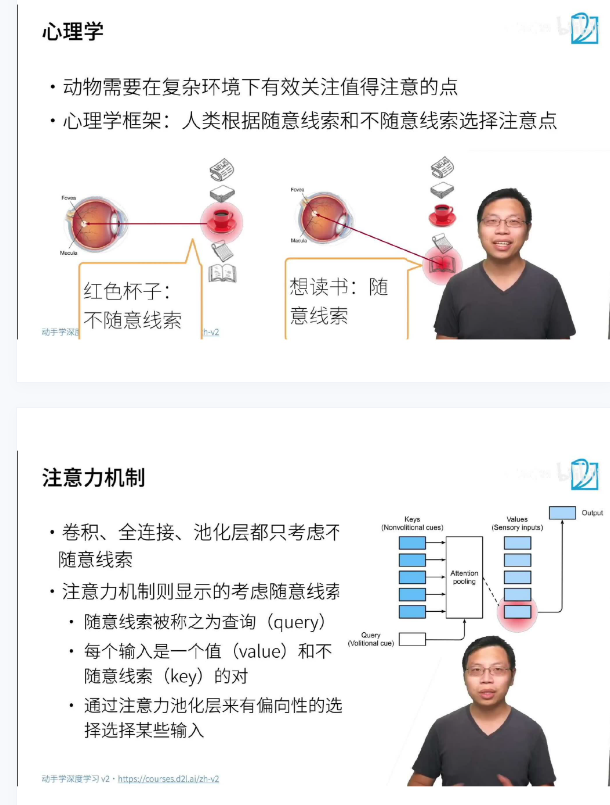
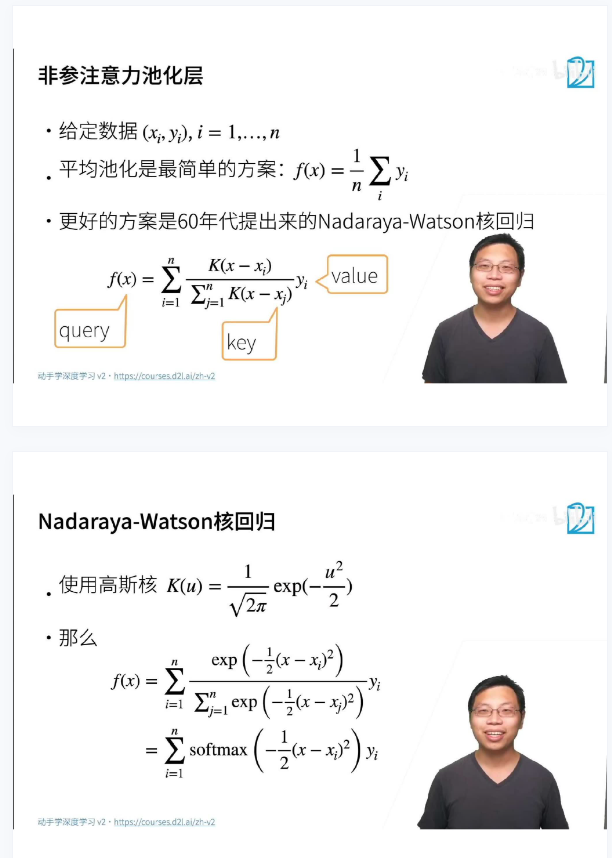
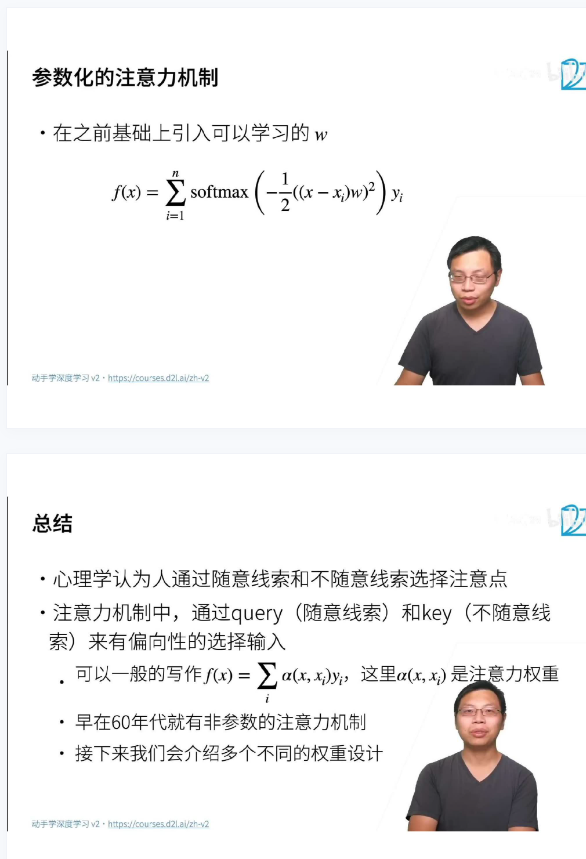
不随意线索是无意识的  随意线索是有意识的


In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本

def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

In [3]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

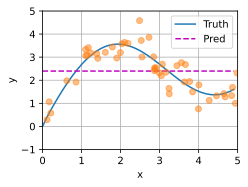

In [4]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)   # 这里直接取平均作为预测值 并不靠谱
plot_kernel_reg(y_hat)

In [6]:
x_train.shape

torch.Size([50])

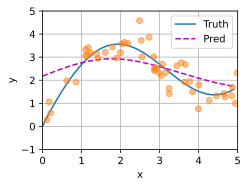

In [7]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
# 每一行相加为1 是按照每一行计算权重的
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

In [8]:
attention_weights.shape

torch.Size([50, 50])

In [9]:
x_test

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000, 1.1000, 1.2000, 1.3000, 1.4000, 1.5000, 1.6000, 1.7000,
        1.8000, 1.9000, 2.0000, 2.1000, 2.2000, 2.3000, 2.4000, 2.5000, 2.6000,
        2.7000, 2.8000, 2.9000, 3.0000, 3.1000, 3.2000, 3.3000, 3.4000, 3.5000,
        3.6000, 3.7000, 3.8000, 3.9000, 4.0000, 4.1000, 4.2000, 4.3000, 4.4000,
        4.5000, 4.6000, 4.7000, 4.8000, 4.9000])

In [12]:
x_test.repeat_interleave(50).reshape(50,50)

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
        [0.2000, 0.2000, 0.2000,  ..., 0.2000, 0.2000, 0.2000],
        ...,
        [4.7000, 4.7000, 4.7000,  ..., 4.7000, 4.7000, 4.7000],
        [4.8000, 4.8000, 4.8000,  ..., 4.8000, 4.8000, 4.8000],
        [4.9000, 4.9000, 4.9000,  ..., 4.9000, 4.9000, 4.9000]])

In [13]:
x_test.repeat_interleave(50).reshape(50,50)-x_train

tensor([[-0.1159, -0.1685, -0.2107,  ..., -4.8695, -4.9406, -4.9852],
        [-0.0159, -0.0685, -0.1107,  ..., -4.7695, -4.8406, -4.8852],
        [ 0.0841,  0.0315, -0.0107,  ..., -4.6695, -4.7406, -4.7852],
        ...,
        [ 4.5841,  4.5315,  4.4893,  ..., -0.1695, -0.2406, -0.2852],
        [ 4.6841,  4.6315,  4.5893,  ..., -0.0695, -0.1406, -0.1852],
        [ 4.7841,  4.7315,  4.6893,  ...,  0.0305, -0.0406, -0.0852]])

In [14]:
nn.functional.softmax(-(x_test.repeat_interleave(50).reshape(50,50)-x_train)**2 / 2, dim=1)
# 第一行的值是0处的点到各个x_train的距离得到的注意力分数  距离越远  分数越低  第二行是0.1

tensor([[1.0814e-01, 1.0733e-01, 1.0648e-01,  ..., 7.7238e-07, 5.4502e-07,
         4.3673e-07],
        [9.9535e-02, 9.9314e-02, 9.8939e-02,  ..., 1.1436e-06, 8.1273e-07,
         6.5417e-07],
        [9.1187e-02, 9.1464e-02, 9.1504e-02,  ..., 1.6853e-06, 1.2062e-06,
         9.7525e-07],
        ...,
        [1.6946e-06, 2.1531e-06, 2.6048e-06,  ..., 6.1076e-02, 6.0193e-02,
         5.9490e-02],
        [1.1398e-06, 1.4559e-06, 1.7687e-06,  ..., 6.6082e-02, 6.5591e-02,
         6.5116e-02],
        [7.6258e-07, 9.7915e-07, 1.1946e-06,  ..., 7.1119e-02, 7.1093e-02,
         7.0894e-02]])

In [17]:
nn.functional.softmax(-(x_test.repeat_interleave(50).reshape(50,50)-x_train)**2 / 2, dim=1).sum(1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [18]:
torch.matmul(attention_weights, y_train)  # 将结果乘以各自的权重相加得到预测值

tensor([2.1771, 2.2438, 2.3097, 2.3744, 2.4376, 2.4987, 2.5574, 2.6132, 2.6657,
        2.7144, 2.7589, 2.7989, 2.8339, 2.8638, 2.8881, 2.9069, 2.9198, 2.9270,
        2.9284, 2.9241, 2.9143, 2.8993, 2.8793, 2.8547, 2.8259, 2.7933, 2.7573,
        2.7182, 2.6765, 2.6325, 2.5866, 2.5392, 2.4905, 2.4408, 2.3905, 2.3398,
        2.2891, 2.2386, 2.1885, 2.1392, 2.0909, 2.0440, 1.9985, 1.9549, 1.9132,
        1.8737, 1.8365, 1.8017, 1.7694, 1.7396])

In [19]:
torch.matmul(attention_weights, y_train[:,None]) 

tensor([[2.1771],
        [2.2438],
        [2.3097],
        [2.3744],
        [2.4376],
        [2.4987],
        [2.5574],
        [2.6132],
        [2.6657],
        [2.7144],
        [2.7589],
        [2.7989],
        [2.8339],
        [2.8638],
        [2.8881],
        [2.9069],
        [2.9198],
        [2.9270],
        [2.9284],
        [2.9241],
        [2.9143],
        [2.8993],
        [2.8793],
        [2.8547],
        [2.8259],
        [2.7933],
        [2.7573],
        [2.7182],
        [2.6765],
        [2.6325],
        [2.5866],
        [2.5392],
        [2.4905],
        [2.4408],
        [2.3905],
        [2.3398],
        [2.2891],
        [2.2386],
        [2.1885],
        [2.1392],
        [2.0909],
        [2.0440],
        [1.9985],
        [1.9549],
        [1.9132],
        [1.8737],
        [1.8365],
        [1.8017],
        [1.7694],
        [1.7396]])

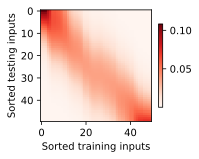

In [20]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')
# 每一行是分数 越深越大  可以看到随着x_test的变化  注意力逐渐从左到右

In [23]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape  # 无视batchsize进行矩阵乘法  但是batchsize的大小需要相同

torch.Size([2, 1, 6])

In [24]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

In [30]:
torch.rand((1,))

tensor([0.2750])

In [31]:
torch.rand(1)

tensor([0.7412])

In [25]:
# w控制高斯窗口的大小  使得曲线突兀一点还是平滑一点
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，“键－值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

In [26]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))


# keys和values都把对角线给拿掉了
# 任何一个训练样本的输入都会和  除自己以外的  所有训练样本的“键－值”对进行计算
# 因为训练的时候自己的值是已经知道的  是标签 所以要去掉标签  也就是去掉对角线


# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

In [34]:
X_tile

tensor([[0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        ...,
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852]])

In [35]:
X_tile[(1 - torch.eye(n_train)).type(torch.bool)]

tensor([0.1685, 0.2107, 0.6224,  ..., 4.8458, 4.8695, 4.9406])

In [36]:
X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

tensor([[0.1685, 0.2107, 0.6224,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.2107, 0.6224,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.6224,  ..., 4.8695, 4.9406, 4.9852],
        ...,
        [0.1159, 0.1685, 0.2107,  ..., 4.8458, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8458, 4.8695, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8458, 4.8695, 4.9406]])

In [33]:
(1 - torch.eye(n_train)).type(torch.bool)

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [ True, False,  True,  ...,  True,  True,  True],
        [ True,  True, False,  ...,  True,  True,  True],
        ...,
        [ True,  True,  True,  ..., False,  True,  True],
        [ True,  True,  True,  ...,  True, False,  True],
        [ True,  True,  True,  ...,  True,  True, False]])

In [32]:
keys

tensor([[0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        ...,
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852]])

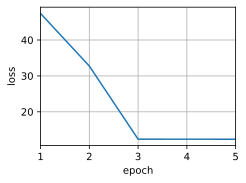

In [27]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

In [37]:
x_train

tensor([0.1159, 0.1685, 0.2107, 0.6224, 0.8571, 1.1019, 1.1060, 1.1454, 1.1731,
        1.2388, 1.3873, 1.4176, 1.6079, 1.7889, 1.9024, 1.9961, 2.0344, 2.1001,
        2.1880, 2.4849, 2.5302, 2.5491, 2.7292, 2.8462, 2.8714, 2.8726, 2.8746,
        2.9055, 2.9921, 3.0436, 3.0702, 3.1621, 3.2403, 3.2483, 3.4441, 3.5585,
        3.6373, 3.6621, 3.7709, 3.8450, 3.9958, 4.0078, 4.2713, 4.4593, 4.6490,
        4.6805, 4.8458, 4.8695, 4.9406, 4.9852])

In [38]:
x_train.repeat((n_test, 1))

tensor([[0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        ...,
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852],
        [0.1159, 0.1685, 0.2107,  ..., 4.8695, 4.9406, 4.9852]])

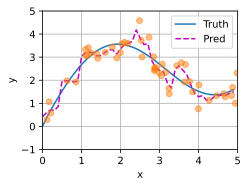

In [28]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）

# 推理的时候 我的注意力在新的n-test个点位上（query）  每一行都是一个点位的注意力分数
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

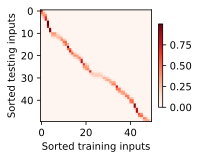

In [29]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')  # 窗口变窄了 只给离x近的权重 其他权重都很小甚至为0

## 注意力分数
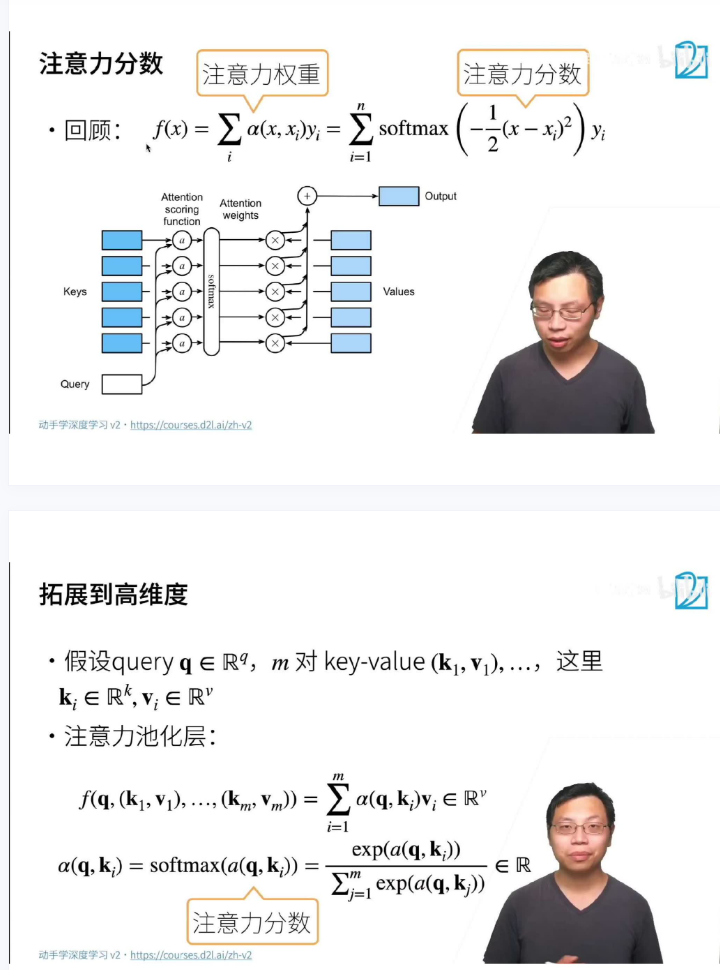
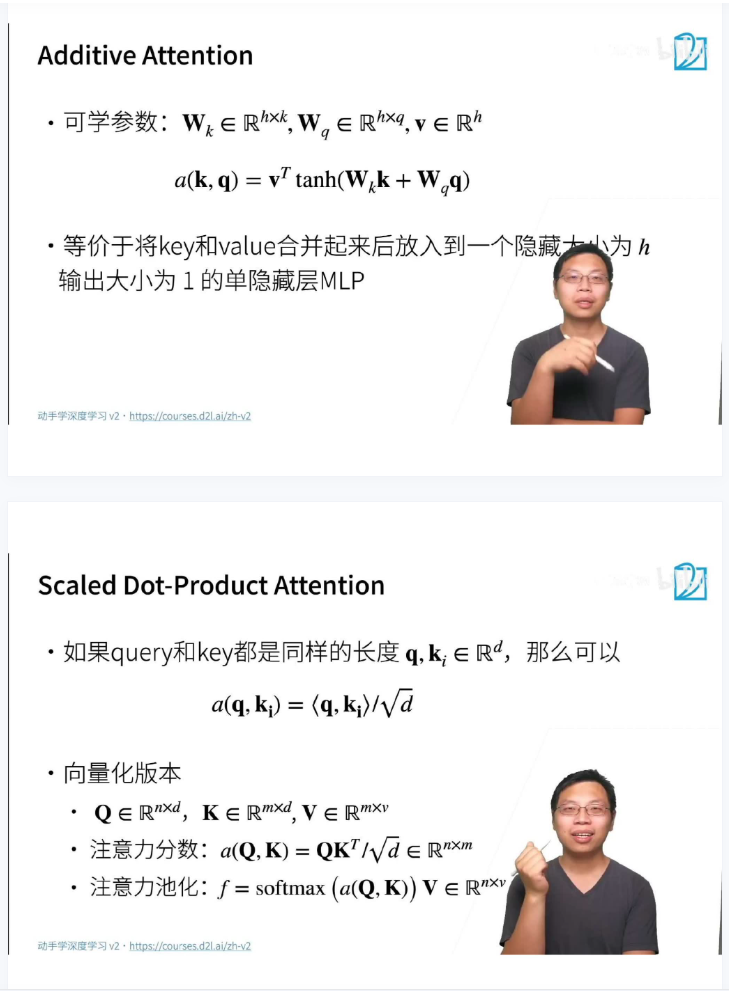
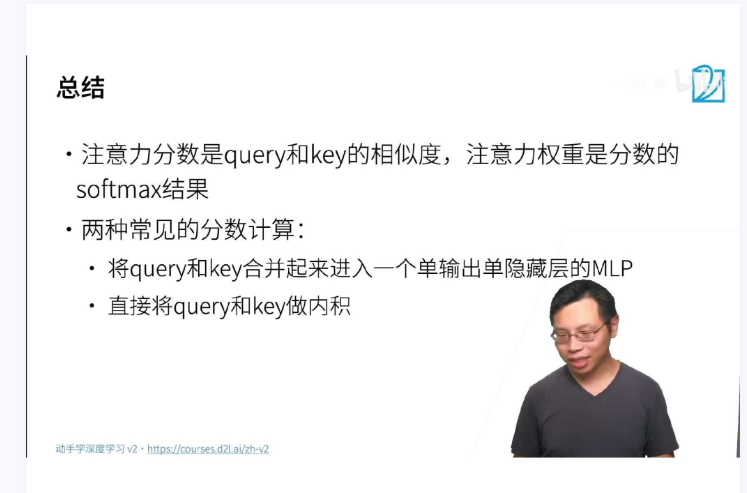
具体流程就是Q和K计算注意力分数 也就是权重分数  然后通过权重分数乘以V 得到最终的结果

additive attention中，两个向量q和k通过一个单隐藏层（其神经元个数为h）后得到两个长为h的向量，再相加，再乘Wv_T(注意这公式应该也不是V_T而是Wv_T)就变成了一个标量，也就是注意力分数。  这里没有concat的过程 用合并不太准确

缩放点积注意力需要最后一维度是相同大小的

介绍了加性注意力和缩放点积注意力   注意力权重是注意力分数softmax以后的结果


queries的形状：(batch_size，查询的个数，q的维度)  # 最后一维度是查询的点位
keys的形状：(batch_size，“键－值”对的个数，k的维度) # 最后一维度是key的点位
values的形状：(batch_size，“键－值”对的个数，值的维度) # 最后一维度是key点位对应出来的值域

In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
#@save
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，valid_lens:1D或2D张量    
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一轴上被掩蔽的元素使用一个非常大的负值替换，从而其softmax输出为0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens,
                              value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [3]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.6117, 0.3883, 0.0000, 0.0000],
         [0.6128, 0.3872, 0.0000, 0.0000]],

        [[0.2485, 0.3792, 0.3723, 0.0000],
         [0.2957, 0.2434, 0.4609, 0.0000]]])

In [4]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3140, 0.4340, 0.2520, 0.0000]],

        [[0.4266, 0.5734, 0.0000, 0.0000],
         [0.1882, 0.2472, 0.2718, 0.2928]]])

In [8]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([1, 3]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000]],

        [[0.3300, 0.2258, 0.4442, 0.0000],
         [0.2868, 0.2858, 0.4274, 0.0000]]])

In [10]:
#@save
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hidden)
        # key的形状：(batch_size，1，“键－值”对的个数，num_hiddens)
        # 使用广播方式进行求和
        # features的形状(batch_size，查询的个数，“键－值”对的个数，num_hiddens)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，“键-值”对的个数)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens) # 过滤掉不需的keyvalue pair
        # values的形状：(batch_size，“键－值”对的个数，值的维度)
        # 这里dropout进一步丢弃了一部分的attention  作为正则项 防止过拟合
        return torch.bmm(self.dropout(self.attention_weights), values) 
        # 结果的形状：(batch_size，查询的个数，值的维度)

In [11]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
# values的小批量，两个值矩阵是相同的
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                              dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

In [12]:
values.shape

torch.Size([2, 10, 4])

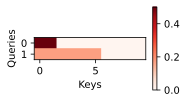

In [13]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')
# 一个前2个  一个前6个

In [19]:
#@save
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries的形状：(batch_size，查询的个数，d)
    # keys的形状：(batch_size，“键－值”对的个数，d)
    # values的形状：(batch_size，“键－值”对的个数，值的维度)
    # valid_lens的形状:(batch_size，)或者(batch_size，查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # 设置transpose_b=True为了交换keys的最后两个维度
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [14]:
a = torch.arange(40).reshape(1,2,4,5)

In [18]:
a.transpose(1,2),a.transpose(1,2).shape

(tensor([[[[ 0,  1,  2,  3,  4],
           [20, 21, 22, 23, 24]],
 
          [[ 5,  6,  7,  8,  9],
           [25, 26, 27, 28, 29]],
 
          [[10, 11, 12, 13, 14],
           [30, 31, 32, 33, 34]],
 
          [[15, 16, 17, 18, 19],
           [35, 36, 37, 38, 39]]]]),
 torch.Size([1, 4, 2, 5]))

In [17]:
a

tensor([[[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],

         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]]]])

In [20]:
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])

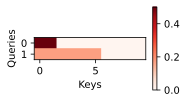

In [21]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

## 使用seq2seq的注意力机制
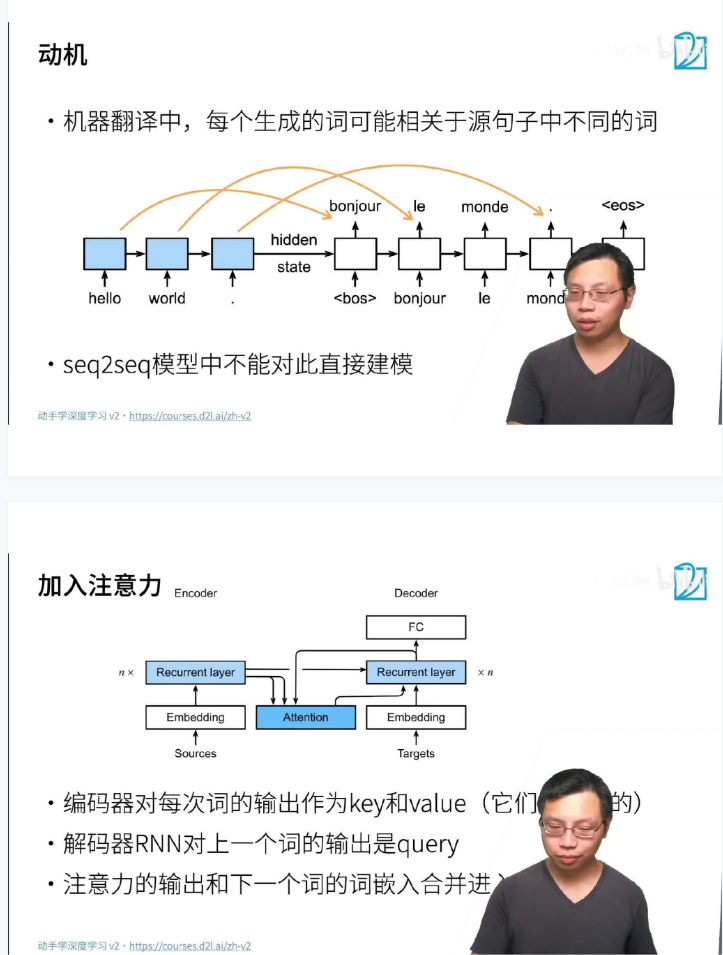
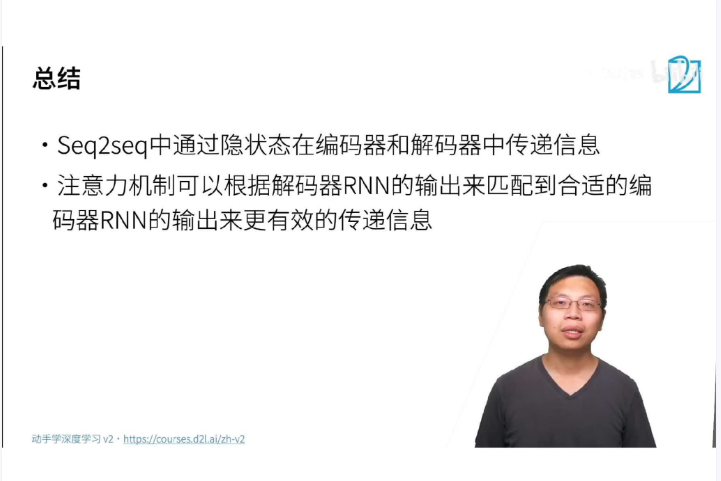
原本就是直接最后一层concat，现在不同了。因为对应位置的关注度应该更高一点，所以加入了注意力机制，其中KV是同一个东西，都是RNN对应位置的输出。因为都是要输出，所以Q也是输出，它是decoder的RNN对应层的输出。

In [22]:
import torch
from torch import nn
from d2l import torch as d2l

In [23]:
#@save
class AttentionDecoder(d2l.Decoder):
    """带有注意力机制解码器的基本接口"""
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    @property
    def attention_weights(self):
        raise NotImplementedError

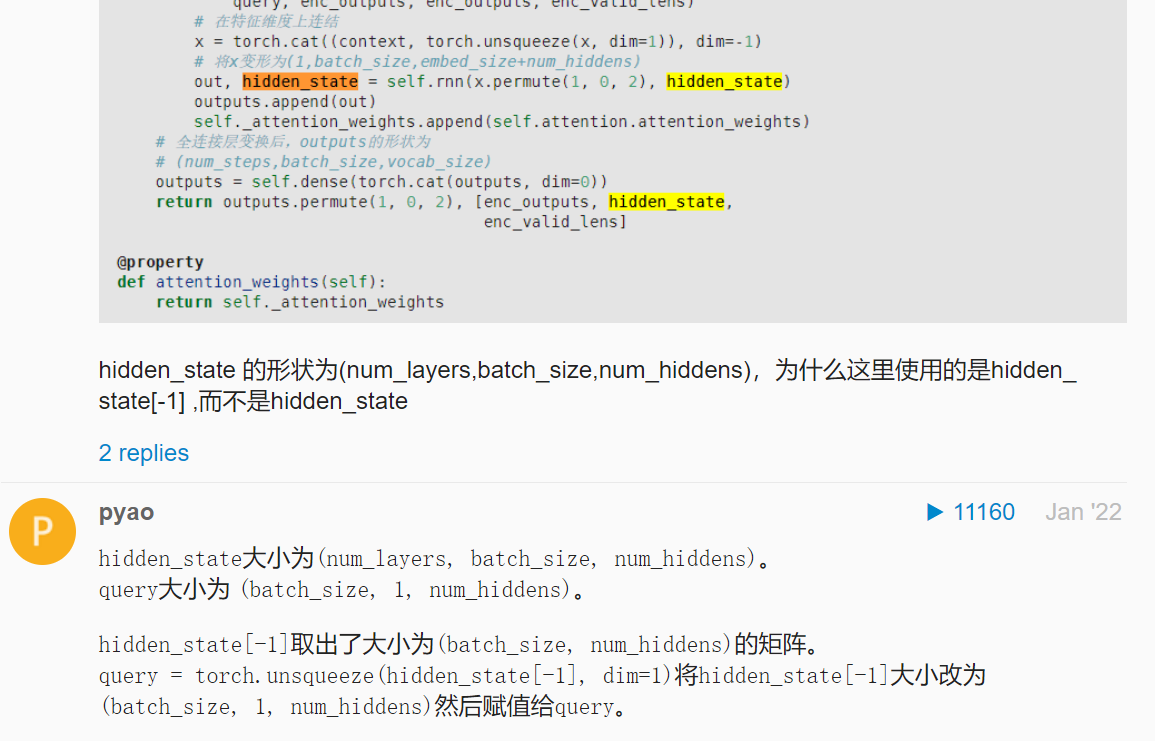

In [28]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        self.attention = AdditiveAttention(
            num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(
            embed_size + num_hiddens, num_hiddens, num_layers,
            dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # outputs的形状为(batch_size，num_steps，num_hiddens).
        # hidden_state的形状为(num_layers，batch_size，num_hiddens)
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        # enc_outputs的形状为(batch_size,num_steps,num_hiddens).  # 前面每一步 每个num_hiddens的值
        # enc_outputssoftmax以后是最后的最大值是以前的输出
        # hidden_state的形状为(num_layers,batch_size,num_hiddens)
        # hidden_state是H  enc_outputs是输出Y
        enc_outputs, hidden_state, enc_valid_lens = state # 最后一个H的输出
        # 输出X的形状为(num_steps,batch_size,embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            # query的形状为(batch_size,1,num_hiddens)
            # 上一个时刻最后一个hidden_state的输出加一个num_query
            query = torch.unsqueeze(hidden_state[-1], dim=1)
            # context的形状为(batch_size,1,num_hiddens)
            # enc_outputs 同时当k也当v
            # enc_valid_lens是一个长为batchsize的向量,每个数值代表能看的长度
            # 因为计算注意力的时候不一定是全重要的 而且pad不需要看 所以有enc_valid_lens
            # 每次的enc_outputs是一样的  但是query是不一样的
            context = self.attention(
                query, enc_outputs, enc_outputs, enc_valid_lens)
            # 在特征维度上连结
            x = torch.cat((context, torch.unsqueeze(x, dim=1)), dim=-1)
            # 将x变形为(1,batch_size,embed_size+num_hiddens)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        # 全连接层变换后，outputs的形状为
        # (num_steps,batch_size,vocab_size)
        outputs = self.dense(torch.cat(outputs, dim=0))
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state,
                                          enc_valid_lens]

    @property
    def attention_weights(self):
        return self._attention_weights 

In [29]:
encoder = d2l.Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16,
                             num_layers=2)
encoder.eval()
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
decoder.eval()
X = torch.zeros((4, 7), dtype=torch.long)  # (batch_size,num_steps)
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)
output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

In [34]:
#@save
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = d2l.MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                     xlim=[10, num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)  # 训练损失总和，词元数量
        for batch in data_iter:
            optimizer.zero_grad()
            # 而我们把Y的最后一个丢掉是因为最后一个不需要作为解码器的输入来预测下一个
            # 其实就相当于“<bos>你好世”到“hello world”
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                          device=device).reshape(-1, 1)  # 注意这里外面框了一个[],否则就是数值乘以
            dec_input = torch.cat([bos, Y[:, :-1]], 1)  # 强制教学 最后一个值被去掉了 因为他不用来预测下一个
            Y_hat = net(X, dec_input, X_valid_len) # X_valid_len没用到这里  后面attention要用到
            l = loss(Y_hat, Y, Y_valid_len) # Y_valid_len前的才计算softmax
            l.sum().backward()      # 损失函数的标量进行“反向传播”
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
        f'tokens/sec on {str(device)}')

loss 0.021, 8615.3 tokens/sec on cuda:0


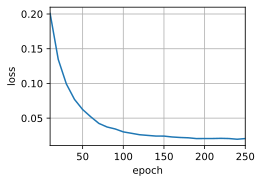

In [35]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 250, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = d2l.Seq2SeqEncoder(
    len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(
    len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = d2l.EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [36]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est riche .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


In [37]:
 attention_weights = torch.cat([step[0][0][0] for step in dec_attention_weight_seq], 0).reshape((
    1, 1, -1, num_steps))

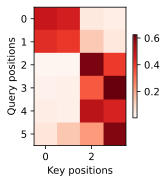

In [38]:
# 加上一个包含序列结束词元
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),
    xlabel='Key positions', ylabel='Query positions')

# 翻译0,1 看的比较前面  
# 横向四个可以认为是hello world.《eos》 四个token

## 自注意力和位置编码
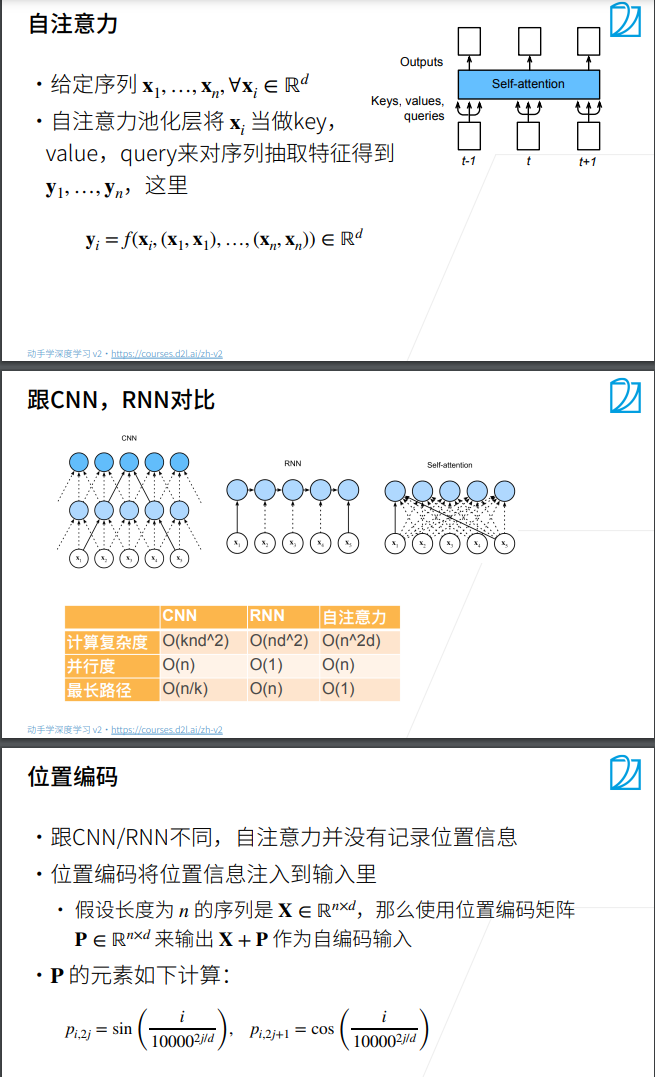
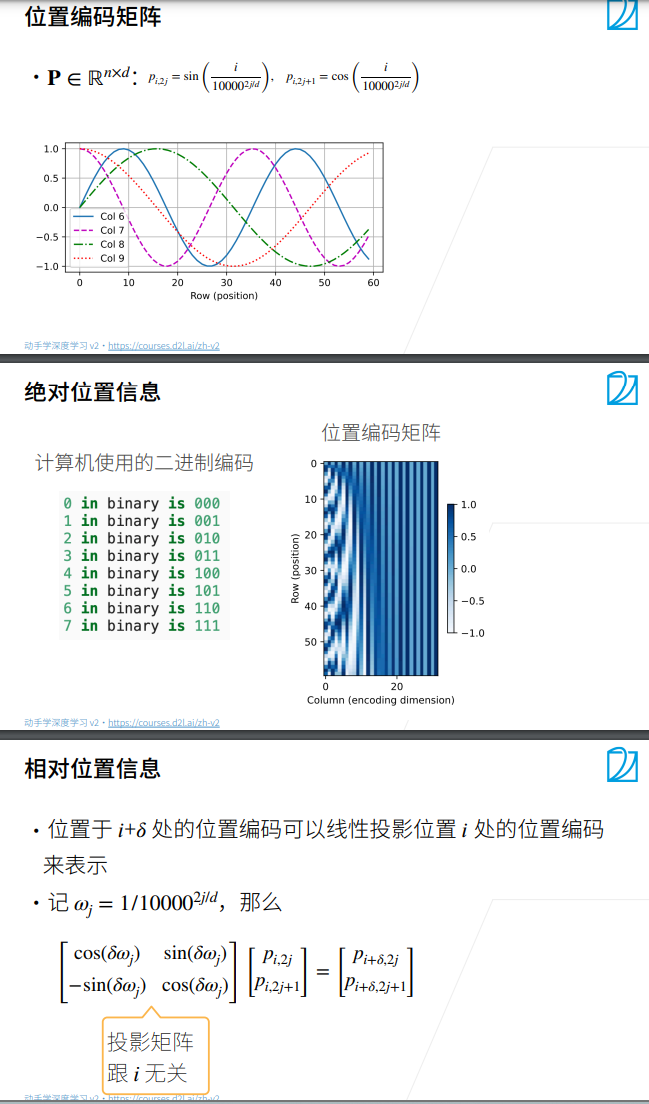

计算复杂度：

CNN：卷积操作的计算复杂度是O(knd^2)，其中k是卷积核的大小，n是序列长度，d是嵌入维度。卷积操作在每个位置上都需要与卷积核进行计算，因此复杂度与序列长度和嵌入维度的乘积成正比。 在图中**k=3**
RNN：循环神经网络的计算复杂度是O(nd^2)，其中n是序列长度，d是隐藏状态的维度。在每个时间步，RNN需要更新隐藏状态，并且每个更新都涉及到一个矩阵乘法操作，因此复杂度与序列长度和隐藏状态维度的乘积成正比。
自注意力：自注意力的计算复杂度是O(n^2d)，其中n是序列长度，d是嵌入维度。自注意力需要计算每个位置与其他位置之间的注意力权重，因此复杂度与序列长度的平方和嵌入维度的乘积成正比。

并行度：

CNN：卷积操作在处理序列时具有并行性，因为在每个位置上都可以同时进行计算，所以并行度为O(n)。
RNN：循环神经网络的计算是按时间步顺序进行的，每个时间步的计算依赖于前一个时间步的结果，因此并行度为O(1)。
自注意力：自注意力的计算可以并行进行，因为每个位置的注意力权重只与其他位置的信息相关，所以并行度为O(n)。

最长路径：

CNN：卷积操作的最长路径是O(n/k)，其中k是卷积核的大小。卷积操作通过滑动窗口在序列上进行计算，每次滑动一个步长，所以最长路径取决于卷积核的大小。
RNN：循环神经网络的最长路径是O(n)，因为每个时间步需要按顺序处理，所以路径长度等于序列的长度。
自注意力：自注意力的最长路径是O(1)，因为每个位置的注意力权重只与其他位置的信息相关，不受序列长度影响。
这些数据是从每种模型的操作和机制推导出来的，可以帮助我们理解它们在计算复杂度、并行度和最长路径方面的特点和差异


位置编码的横坐标是i。j代表不同颜色的曲线，这个图像竖着画一条竖线  就是一个token的位置。col6是偶数，所以是sin函数，col7是奇数，所以是cos函数。位置编码矩阵中，每一行是一个编码，可以看到这个是前面编码变化得快，后面编码变化得慢，和二进制是相反的。最后的旋转矩阵可以理解为坐标系里的坐标旋转，从而得到这个点对应的相对位置的token

In [39]:
import math
import torch
from torch import nn
from d2l import torch as d2l

In [40]:
num_hiddens, num_heads = 100, 5
attention = d2l.MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,
                                   num_hiddens, num_heads, 0.5)
attention.eval()

TypeError: __init__() takes from 4 to 5 positional arguments but 7 were given

In [42]:
#@save
class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # 创建一个足够长的P
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)  # 在数据上直接加入位置数据
        return self.dropout(X)  # 避免模型对P太过敏感

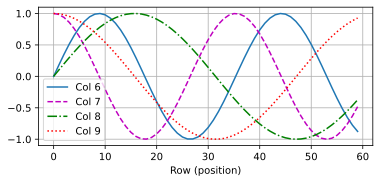

In [43]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
pos_encoding.eval()
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, :X.shape[1], :]
d2l.plot(torch.arange(num_steps), P[0, :, 6:10].T, xlabel='Row (position)',
         figsize=(6, 2.5), legend=["Col %d" % d for d in torch.arange(6, 10)])

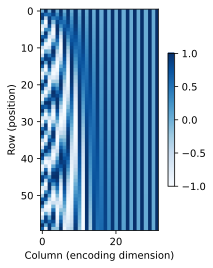

In [44]:
P = P[0, :, :].unsqueeze(0).unsqueeze(0)
d2l.show_heatmaps(P, xlabel='Column (encoding dimension)',
                  ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')

## transformer
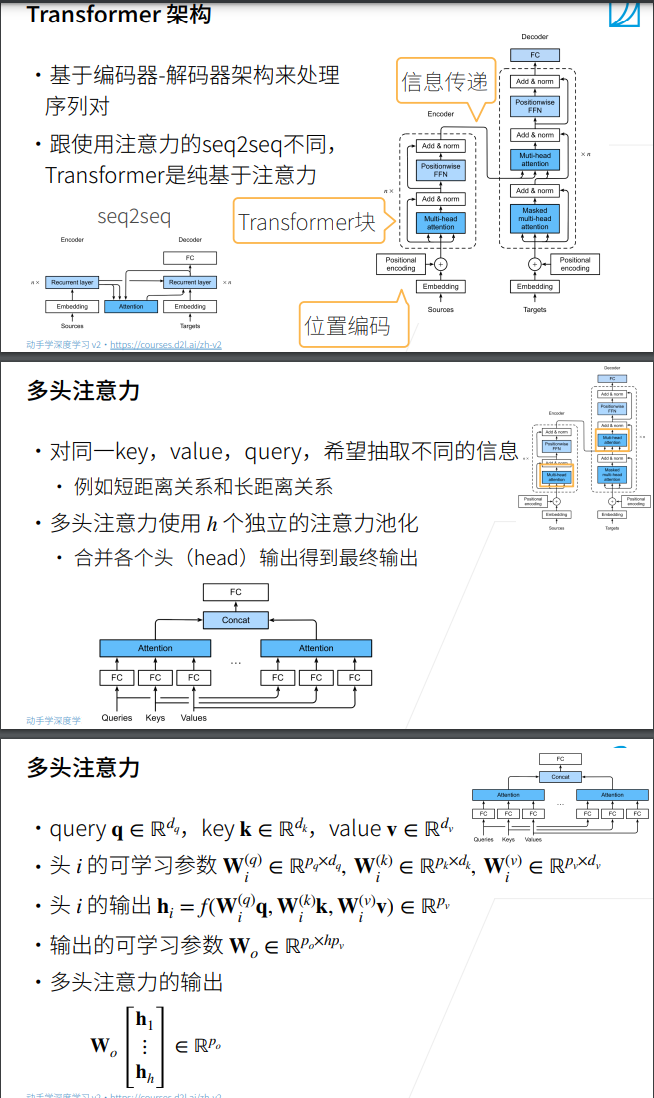
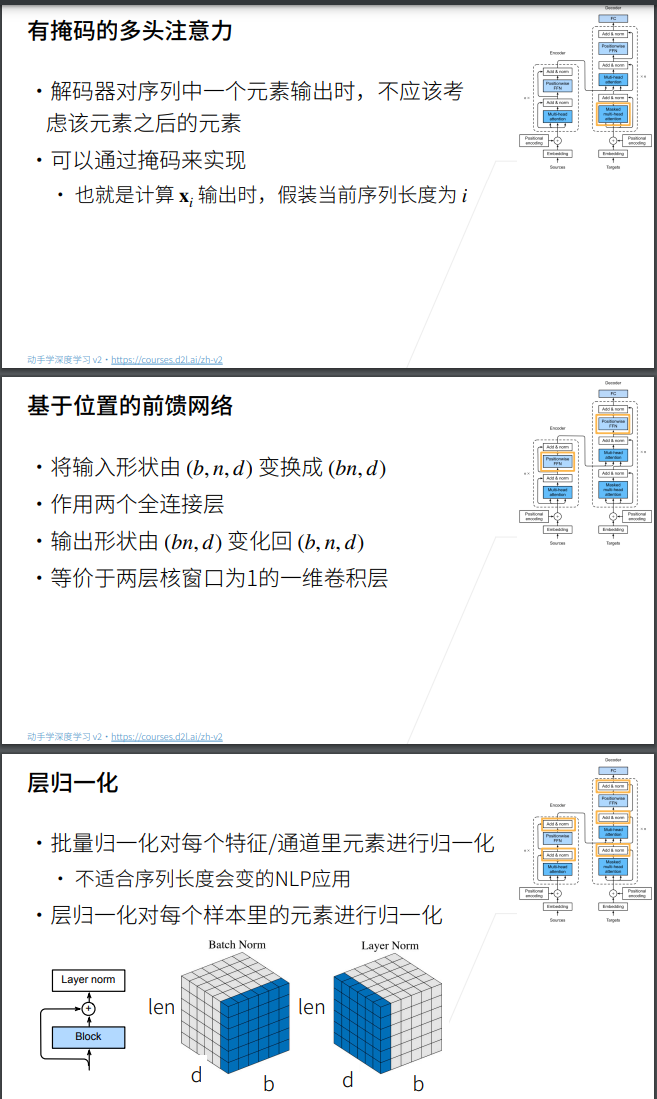
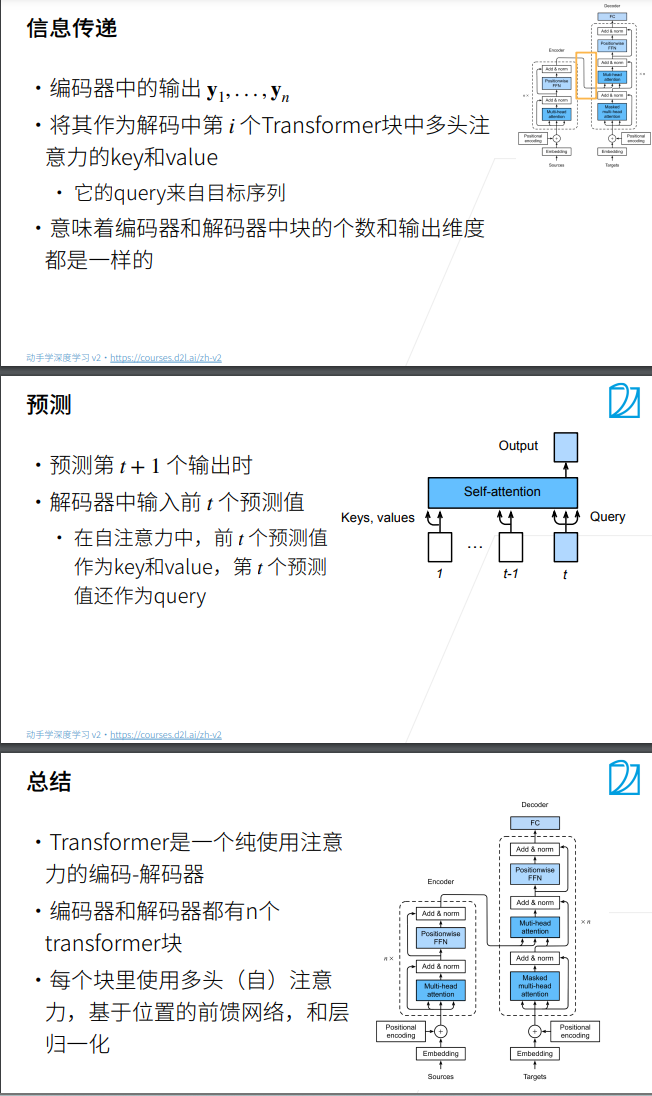

多头注意力就是使用h个独立的注意力池化，之后合并各个头输出得到最终的结果。不同的注意力关注点不同，比如短距离关系和长距离关系。

decoder一开始会进行掩码的多头注意力，主要是预测的时候不应该考虑元素之后的元素


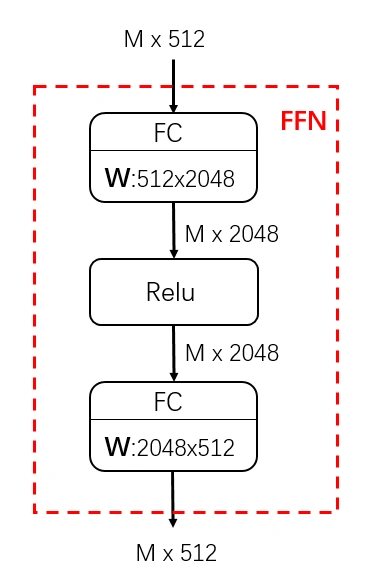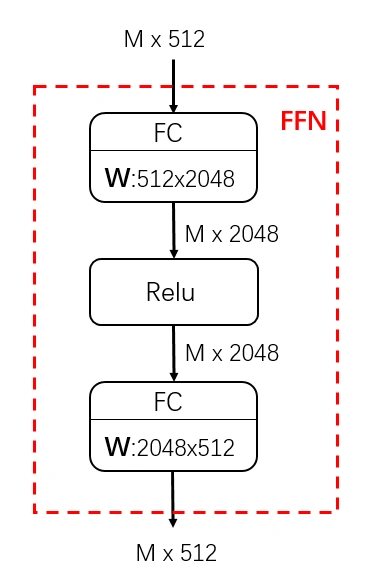
FFN大概因为，FFN的输入，linear函数只能写 input_embed, 和output_embed这两个参数, 所以得切换成二维的形式输入。既然 FFN 的输入和输出的维度都一样，那为什么还要加这个结构呢？

增加了两个可学习的权值矩阵，也就是上面表达公式中的两个 W 矩阵。通过和权值矩阵的相乘将输入 512 维度向量映射到隐层的 2048 维度空间中，使得输入数据可以完成更加丰富的特征表达和运算。虽然FFN的输入输出维度都是512，但是输出的512维度特征和输入的512为特征是不一样的。输出的512维度特征是在隐层空间（2048）的基础上进一步融合得到的。可以说，输出的512维比输入的512维具有更加丰富和准确的特征表示。

层归一化中。左图，不同样本中的某一个维度特征进行归一化； 右图，同一个样本中的所有特征进行归一化。len是样本个数，d是维度，b是batchsize

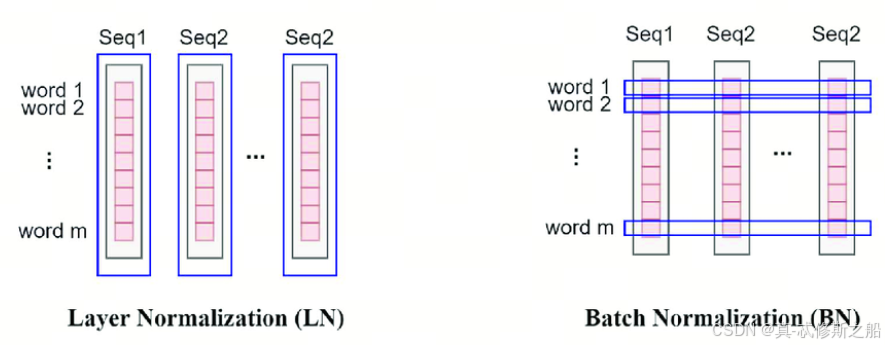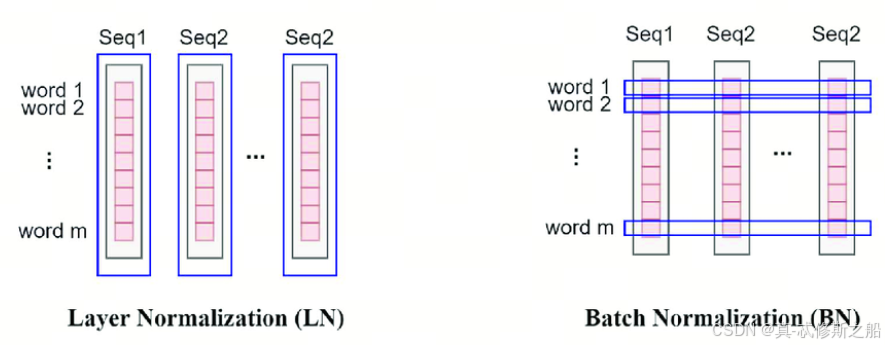

每个batch里面len的长度实际上是不同的，BatchNorm的计算是在整个批量数据上进行的，因此其在不同批次间的统计信息可能会有所波动，导致模型训练的不稳定性。（因为len不断地变化）LayerNorm是对每个样本独立地进行规范化，而BatchNorm则是对整个批量的数据进行归一化。

In [1]:
import math
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [17]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention.

    Defined in :numref:`sec_multihead-attention`"""
    def __init__(self, key_size, query_size, value_size, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # Shape of queries, keys, or values:
        # (batch_size, no. of queries or key-value pairs, num_hiddens)
        # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
        # After transposing, shape of output queries, keys, or values:
        # (batch_size * num_heads, no. of queries or key-value pairs,
        # num_hiddens / num_heads)
        queries = transpose_qkv(self.W_q(queries),self.num_heads)
        keys = transpose_qkv(self.W_k(keys),self.num_heads)
        values = transpose_qkv(self.W_v(values),self.num_heads)

        if valid_lens is not None:  # masked
            # On axis 0, copy the first item (scalar or vector) for num_heads
            # times, then copy the next item, and so on
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # Shape of output: (batch_size * num_heads, no. of queries,
        # num_hiddens / num_heads)
        output = self.attention(queries, keys, values, valid_lens)
        # Shape of output_concat: (batch_size, no. of queries, num_hiddens)
        output_concat = transpose_output(output,self.num_heads)
        return self.W_o(output_concat)

In [3]:
def transpose_qkv(X, num_heads):
        """Transposition for parallel computation of multiple attention heads.
    
        Defined in :numref:`sec_multihead-attention`"""
        # Shape of input X: (batch_size, no. of queries or key-value pairs,
        # num_hiddens). Shape of output X: (batch_size, no. of queries or
        # key-value pairs, num_heads, num_hiddens / num_heads)
        X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
        # Shape of output X: (batch_size, num_heads, no. of queries or key-value
        # pairs, num_hiddens / num_heads)
        X = X.permute(0, 2, 1, 3)
        # Shape of output: (batch_size * num_heads, no. of queries or key-value
        # pairs, num_hiddens / num_heads)
        return X.reshape(-1, X.shape[2], X.shape[3])

In [4]:
class C:
    def __init__(self):
        self.a = 3



In [5]:
def good(self):  # 可以在class的外面定义有关self的函数  但是要把对象传输进去
    print(self.a)

In [7]:
c =C()

In [8]:
c.a

3

In [11]:
good(c)

3


In [19]:
def transpose_output(X, num_heads):
    # 你转transpose_qkv函数的操作
    X = X.reshape(-1, num_heads, X.shape[1],X.shape[2])
    X = X.permute(0,2,1,3)
    return X.reshape(X.shape[0], X.shape[1], -1)

[b,n,h]--[b,n,m,h/m]--[b,m,n,h/m]--[bm,n,h/m]

batch,len,hidden,multihead

相当于将batchsize多了multihead倍  再进行并行计算

In [28]:
num_hiddens, num_heads = 100,5
attention = MultiHeadAttention(num_hiddens, num_hiddens,num_hiddens,num_hiddens,num_heads,.5)
attention.eval()
# Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
# 第一个batch知道前2个  第二个batch知道前4个的意思
batch_size, num_queries, num_kvpairs, valid_lens = 2,4,6,torch.tensor([2,4])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_queries, num_hiddens))
attention(X,Y,Y,valid_lens).shape
# Shape of output_concat: (batch_size, no. of queries, num_hiddens)

torch.Size([2, 4, 100])

什么形状进去 什么形状出来

In [22]:
s = torch.tensor([2,4])

In [26]:
torch.repeat_interleave(s,5,dim=0)  # 给每个头都相同的masked

tensor([2, 2, 2, 2, 2, 4, 4, 4, 4, 4])

In [1]:
import math
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
#@save  实际上就是一个mlp
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [3]:
ffn = PositionWiseFFN(4, 4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[-0.3295,  0.2280, -0.0045,  0.0292,  0.0031,  0.4542, -0.0523, -0.3595],
        [-0.3295,  0.2280, -0.0045,  0.0292,  0.0031,  0.4542, -0.0523, -0.3595],
        [-0.3295,  0.2280, -0.0045,  0.0292,  0.0031,  0.4542, -0.0523, -0.3595]],
       grad_fn=<SelectBackward0>)

In [5]:
ffn(torch.ones((2, 3, 4))).shape  # 会对最后一个维度变化

torch.Size([2, 3, 8])

layernorm把整个样本变成均值为0 方差为1，  batchnorm把整个特征变成均值为0方差为1

In [6]:
ln = nn.LayerNorm(2)
bn = nn.BatchNorm1d(2)
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# 在训练模式下计算X的均值和方差
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [7]:
#@save
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [8]:
add_norm = AddNorm([3, 4], 0.5)
add_norm.eval()
add_norm(torch.ones((2, 3, 4)), torch.ones((2, 3, 4))).shape  # 不会改变输入输出的形状

torch.Size([2, 3, 4])

In [14]:
#@save
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = d2l.MultiHeadAttention(
             num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [16]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = EncoderBlock( 24, [100, 24], 24, 48, 8, 0.5)
encoder_blk.eval()
encoder_blk(X, valid_lens).shape  # 输出形状不会变

torch.Size([2, 100, 24])

In [18]:
encoder_blk.attention

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=24, out_features=24, bias=False)
  (W_k): Linear(in_features=24, out_features=24, bias=False)
  (W_v): Linear(in_features=24, out_features=24, bias=False)
  (W_o): Linear(in_features=24, out_features=24, bias=False)
)

In [19]:
encoder_blk.attention.attention

DotProductAttention(
  (dropout): Dropout(p=0.5, inplace=False)
)

In [20]:
encoder_blk.attention.attention.attention_weights

tensor([[[0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
         [0.3333, 0.3333, 0.3333,  ..., 0.0000, 0.0000, 0.

In [24]:
#@save
class TransformerEncoder(d2l.Encoder):
    """Transformer编码器"""
    def __init__(self, vocab_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # 因为位置编码值在-1和1之间，
        # 因此嵌入值乘以嵌入维度的平方根进行缩放，
        # 然后再与位置编码相加。
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

In [26]:
encoder = TransformerEncoder(
    200, 24, [100, 24], 24, 48, 8, 2, 0.5)
encoder.eval()
encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape  # encoder的输出

torch.Size([2, 100, 24])

In [27]:
class DecoderBlock(nn.Module):
    """解码器中第i个块"""
    def __init__(self, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = d2l.MultiHeadAttention(
             num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = d2l.MultiHeadAttention(
             num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens,
                                   num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # 训练阶段，输出序列的所有词元都在同一时间处理，
        # 因此state[2][self.i]初始化为None。
        # 预测阶段，输出序列是通过词元一个接着一个解码的，
        # 因此state[2][self.i]包含着直到当前时间步第i个块解码的输出表示
        # training的时候，会把正确的内容放入decorder，因为是自注意力，所以qkv就是他本身
        # 训练时，decoding的输入就是翻译结果。测试时，decoding的输入要比出少一个单词比如输入（我，我，我）
        # ->decoding的输入就是（‘mask’，me，me）其中mask为填充
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # dec_valid_lens的开头:(batch_size,num_steps),
            # 其中每一行是[1,2,...,num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        # 自注意力
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # 编码器－解码器注意力。
        # 编码器的输出
        # enc_outputs的开头:(batch_size,num_steps,num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [29]:
decoder_blk = DecoderBlock( 24, [100, 24], 24, 48, 8, 0.5, 0)
decoder_blk.eval()
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
decoder_blk(X, state)[0].shape

torch.Size([2, 100, 24])

In [31]:
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, 
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size) # 最后有一个输出

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens)) # 防止太小
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # 解码器自注意力权重
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # “编码器－解码器”自注意力权重  为了后续可视化的
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

In [34]:
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """Train a model for sequence to sequence.

    Defined in :numref:`sec_utils`"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)  # Sum of training loss, no. of tokens
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)
            dec_input = d2l.concat([bos, Y[:, :-1]], 1)  # Teacher forcing
            Y_hat = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()  # Make the loss scalar for `backward`
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
          f'tokens/sec on {str(device)}')

In [38]:
def sequence_mask(X, valid_len, value=0):
    """Mask irrelevant entries in sequences.

    Defined in :numref:`sec_utils`"""
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

In [36]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """The softmax cross-entropy loss with masks.

    Defined in :numref:`sec_utils`"""
    # `pred` shape: (`batch_size`, `num_steps`, `vocab_size`)
    # `label` shape: (`batch_size`, `num_steps`)
    # `valid_len` shape: (`batch_size`,)
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

最重要的超参数  num_hiddens num_heads

loss 0.029, 10097.1 tokens/sec on cuda:0


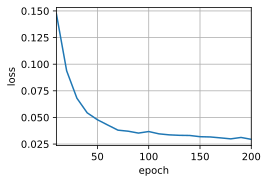

In [39]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, d2l.try_gpu()
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
decoder = TransformerDecoder(
    len(tgt_vocab), num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
net = d2l.EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [42]:
enc_attention_weights = torch.cat(net.encoder.attention_weights, 0).reshape((num_layers, num_heads,
    -1, num_steps))
enc_attention_weights.shape

torch.Size([2, 4, 10, 10])

In [43]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est calme .,  bleu 1.000
i'm home . => je suis chez moi .,  bleu 1.000


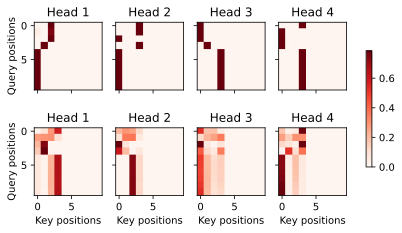

In [44]:
d2l.show_heatmaps(
    enc_attention_weights.cpu(), xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))
# 每一行一个query 每一列一个key-value pair

# 2个layer  4个multiheads

In [45]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weight_seq
                            for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
dec_attention_weights = dec_attention_weights_filled.reshape((-1, 2, num_layers, num_heads, num_steps))
dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)
dec_self_attention_weights.shape, dec_inter_attention_weights.shape

(torch.Size([2, 4, 6, 10]), torch.Size([2, 4, 6, 10]))

由于解码器自注意力的自回归属性，查询不会对当前位置之后的“键－值”对进行注意力计算。

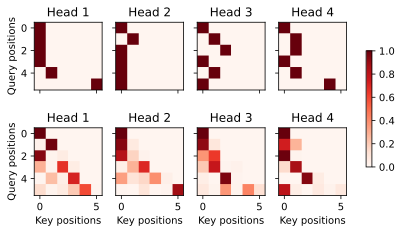

In [46]:
# Plusonetoincludethebeginning-of-sequencetoken
# encoder decoder之间的注意力机制  偏后的词看编码偏后的词
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :len(translation.split()) + 1],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))

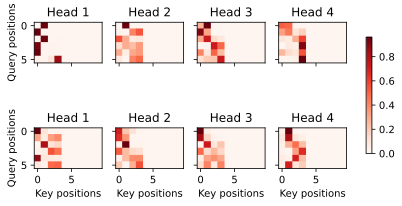

In [47]:
# 与编码器的自注意力的情况类似，通过指定输入序列的有效长度，
# 输出序列的查询不会与输入序列中填充位置的词元进行注意力计算。
d2l.show_heatmaps(
    dec_inter_attention_weights, xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))